In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey
from pathlib import Path
from scipy.signal import welch

In [ ]:
def window_organ_signal(signal, sample_rate, start_sec, end_sec, fade_fraction=0.1):

    """
    Ritaglia il segnale e applica una finestra di Tukey per evitare click e leakage.
    
    signal: Array numpy del segnale audio.
    sample_rate: Frequenza di campionamento.
    start_sec: Secondo di inizio del taglio.
    end_sec: Secondo di fine del taglio.
    fade_fraction: Percentuale della finestra dedicata al fade (0-1).
    return: Segnale ritagliato e finestrato.
    """

    # 1. Ritaglio temporale
    start_sample = int(start_sec * sample_rate)
    end_sample = int(end_sec * sample_rate)
    trimmed_signal = signal[start_sample:end_sample]
    
    # 2. Creazione della finestra di Tukey
    # fade_fraction definisce quanto i bordi sono smussati.
    # Se 0 è una rettangolare, se 1 è una finestra di Hann.
    win = tukey(len(trimmed_signal), alpha = fade_fraction)
    
    # 3. Applicazione
    windowed_signal = trimmed_signal * win
    
    return windowed_signal

In [19]:
def process_organ_notes(folder_path, start_sec=0.5, end_sec=2.5):
    
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        samplerate, data = wavfile.read(file_path)
        
        # 1. Normalizzazione e gestione Stereo -> Mono
        if data.dtype == np.int16:
            data = data / 32768.0
            
        if len(data.shape) > 1:
            signal = np.mean(data, axis=1)
        else:
            signal = data

        # 2. CHIAMATA ALLA FUNZIONE ESTERNA
        # Usiamo la funzione che abbiamo scritto prima!
        final_signal = window_organ_signal(signal, samplerate, start_sec, end_sec)
        
        # 3. FFT e Analisi
        n = len(final_signal)
        fft_values = np.fft.fft(final_signal)
        frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2]
        power_spectrum = np.abs(fft_values[:n//2])**2
        
        results[file_path.name] = {
            'freq': frequencies,
            'psd': power_spectrum,
            'rate': samplerate
        }
        print(f"Elaborato: {file_path.name}")

    return results

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_27841/3309794699.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


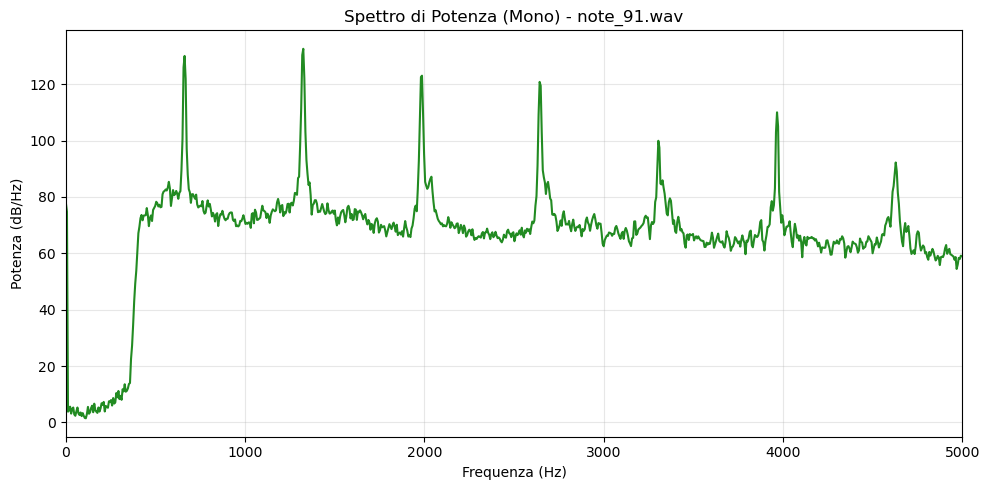

In [ ]:
"""Il Problema: La FFT "Grezza" (Periodogramma)
Se prendi un segnale intero (come hai fatto all'inizio del tuo notebook) e gli applichi una singola, gigantesca Trasformata di Fourier (FFT), ottieni un risultato molto instabile. Se c'è anche un minimo rumore di fondo, il grafico esploderà in una miriade di picchi "seghettati" e frastagliati. Questo fenomeno si chiama alta varianza: il risultato varia tantissimo a causa del rumore casuale, nascondendo le vere frequenze del segnale.

La Soluzione: Il Metodo di Welch
Il metodo di Welch risolve questo problema usando la statistica, in particolare la forza della media matematica. Lo fa in 4 passaggi fondamentali:

1.⁠ ⁠Segmentazione (Divisione in blocchi)
Invece di fare una singola FFT lunga quanto tutto il file audio, Welch prende il segnale e lo "affetta" in tanti blocchi più corti. La lunghezza di questi blocchi è il famoso parametro nperseg (Number of Points PER SEGment).

2.⁠ ⁠Sovrapposizione (Overlap)
Se tagliassimo il segnale come se fossero mattoni, perderemmo delle informazioni proprio nei punti di taglio. Per evitare questo, i segmenti vengono fatti sovrapporre (di solito del 50%). Quindi il primo segmento va da 0 a 1000, il secondo va da 500 a 1500, il terzo da 1000 a 2000, e così via.

3.⁠ ⁠Finestratura (Windowing)
A ciascuno di questi segmenti viene applicata una "finestra" matematica (spesso chiamata finestra di Hann o Hamming). Questa curva smussa i bordi di ogni singolo segmento portandoli dolcemente a zero. Questo previene un brutto difetto matematico chiamato Spectral Leakage (dispersione spettrale), che altrimenti creerebbe frequenze fantasma che non esistono davvero.

4.⁠ ⁠FFT e Media
A questo punto, il metodo calcola la potenza della FFT per ogni singolo segmento. Se hai diviso il file in 100 pezzetti, avrai 100 grafici FFT separati. Infine, fa la media di tutti questi 100 grafici.

Il risultato e il "Compromesso di Welch"
Facendo la media, il rumore casuale di fondo si annulla a vicenda (perché a volte va su, a volte va giù), mentre le frequenze stabili (come la nota del tuo organo) si sommano e si confermano. Il risultato è quel grafico bellissimo e smussato che hai ottenuto.

C'è però un compromesso fondamentale (Trade-off) che devi decidere quando scegli il parametro nperseg:

nperseg PICCOLO (es. 256): Avrai tantissimi segmenti di cui fare la media. Il grafico sarà incredibilmente liscio e senza rumore, ma i picchi saranno molto larghi e "cicciotti" (poca risoluzione in frequenza). Farai fatica a distinguere due frequenze molto vicine.

nperseg GRANDE (es. 4096 o 8192): Avrai pochi segmenti di cui fare la media. I picchi saranno sottilissimi e precisi (altissima risoluzione in frequenza), ma la linea di base tornerà ad essere un po' frastagliata e rumorosa."""

def analizza_nota_welch_mono(file_path, start_sec=0.5, end_sec=1.5, nperseg=8192):
    """
    Converte in mono, ritaglia e calcola lo spettro mediato.
    """
    # 1. Caricamento e Normalizzazione
    samplerate, data = wavfile.read(file_path)
    if data.dtype == np.int16:
        data = data / 32768.0

    # 2. Conversione in MONO (Media dei canali)
    if len(data.shape) > 1:
        signal_mono = np.mean(data, axis=1)
    else:
        signal_mono = data

    # 3. Ritaglio e Windowing (Sostegno)
    # Usiamo la tua funzione window_organ_signal
    signal_cut = window_organ_signal(signal_mono, samplerate, start_sec, end_sec, fade_fraction=0.05)

    # 4. Calcolo PSD con Welch
    # Ho alzato nperseg a 8192 per darti più risoluzione sulle note basse
    freqs, psd = welch(signal_cut, fs=samplerate, nperseg=nperseg)

    # 5. Plotting (Singolo grafico, molto più chiaro)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, 10 * np.log10(psd + 1e-12), color='forestgreen')
    plt.title(f"Spettro di Potenza (Mono) - {Path(file_path).name}")
    plt.xlabel('Frequenza (Hz)')
    plt.ylabel('Potenza (dB/Hz)')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 5000) 
    plt.tight_layout()
    plt.show()
    
    return freqs, psd

freqs, psd = analizza_nota_welch_mono('data/note_91.wav')